Imports

# Task 3: Opposition & Match Context Analysis

## Research Question
How much does the opponent and match importance drive fans through the gate?

This analysis investigates how different match context factors influence attendance at OH Leuven home matches.  
In particular, we focus on the following variables:

- Opponent (`away_team`)
- Match importance (`stage`)
- Matchday
- Last result against the opponent
- Competition and season

The goal is to understand which factors attract more fans to the stadium and how strong their influence is on attendance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Converting CSV files to DataFrames
gold_match_df = pd.read_csv('../data/raw/gold_match.csv', sep=',', on_bad_lines='skip')
gold_match_context_df = pd.read_csv('../data/raw/gold_match_context.csv', sep=',', on_bad_lines='skip')

In [4]:
# Filter to home games only
home_matches = gold_match_df[gold_match_df['is_home_match'] == True]

# Select relevant columns from match dataset
match_features = home_matches[
    [
        'match_id',
        'match_date',
        'away_team',
        'stage',
        'competition_name',
        'season',
        'matchday',
        'last_result_vs_opponent',
        'tickets_scanned'
    ]
]

# Merge with context table
gold_match_context_df = gold_match_context_df.merge(
    match_features,
    on='match_id',
    how='inner'
)

print(f"Home games for analysis: {len(gold_match_context_df)}")
gold_match_context_df.head(5)

Home games for analysis: 71


,match_id,match_date_x,weather_temp_max_c,weather_temp_min_c,weather_temp_mean_c,weather_precipitation_mm,weather_rain_mm,weather_snowfall_cm,weather_windspeed_max_kmh,weather_sunshine_hours,...,pct_free_tickets,campaign_motto,match_date_y,away_team,stage,competition_name,season,matchday,last_result_vs_opponent,tickets_scanned
0,d256yo3eng04m0fu7b4sl7wno,2022-07-30,25.8,12.9,19.8,0.0,0.0,0.0,10.2,10.3,...,13.9,NaN,2022-07-30,Westerlo,Regular Season,Belgian Jupiler Pro League,2022/2023,2.0,NaN,5565.0
1,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,32.2,17.3,25.4,0.0,0.0,0.0,16.9,11.1,...,8.3,NaN,2022-08-14,Club Brugge,Regular Season,Belgian Jupiler Pro League,2022/2023,4.0,L 1-4,7440.0
2,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,21.0,15.9,18.7,0.0,0.0,0.0,13.7,3.9,...,14.8,NaN,2022-08-27,KV Oostende,Regular Season,Belgian Jupiler Pro League,2022/2023,6.0,W 3-1,4489.0
3,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,18.9,13.6,15.7,8.6,8.6,0.0,23.5,4.1,...,68.7,NaN,2022-09-10,Sporting Charleroi,Regular Season,Belgian Jupiler Pro League,2022/2023,8.0,W 3-0,4508.0
4,dak40etbhbqsr1nxyt50qcg0k,2022-10-01,17.8,10.9,14.2,9.8,9.8,0.0,34.5,8.5,...,7.5,NaN,2022-10-01,Union Saint-Gilloise,Regular Season,Belgian Jupiler Pro League,2022/2023,10.0,L 1-4,6290.0


In [5]:
analysis_df = gold_match_context_df[
    [
        'match_id',
        'match_date_y',
        'away_team',
        'stage',
        'competition_name',
        'season',
        'matchday',
        'last_result_vs_opponent',
        'tickets_scanned'
    ]
].copy()

# rename column for clarity
analysis_df = analysis_df.rename(columns={'match_date_y': 'match_date'})

analysis_df['match_date'] = pd.to_datetime(analysis_df['match_date'])

print(analysis_df.head())

                    match_id match_date             away_team           stage  \
0  d256yo3eng04m0fu7b4sl7wno 2022-07-30              Westerlo  Regular Season   
1  d4mn5ksbxuvnaww4pmommxhqs 2022-08-14           Club Brugge  Regular Season   
2  d65hmi7sq03yzr5he1k7ypus4 2022-08-27           KV Oostende  Regular Season   
3  d80mkemezkz16bqh6lbn8tlhw 2022-09-10    Sporting Charleroi  Regular Season   
4  dak40etbhbqsr1nxyt50qcg0k 2022-10-01  Union Saint-Gilloise  Regular Season   

             competition_name     season  matchday last_result_vs_opponent  \
0  Belgian Jupiler Pro League  2022/2023       2.0                     NaN   
1  Belgian Jupiler Pro League  2022/2023       4.0                   L 1-4   
2  Belgian Jupiler Pro League  2022/2023       6.0                   W 3-1   
3  Belgian Jupiler Pro League  2022/2023       8.0                   W 3-0   
4  Belgian Jupiler Pro League  2022/2023      10.0                   L 1-4   

   tickets_scanned  
0           5565.0  
1 

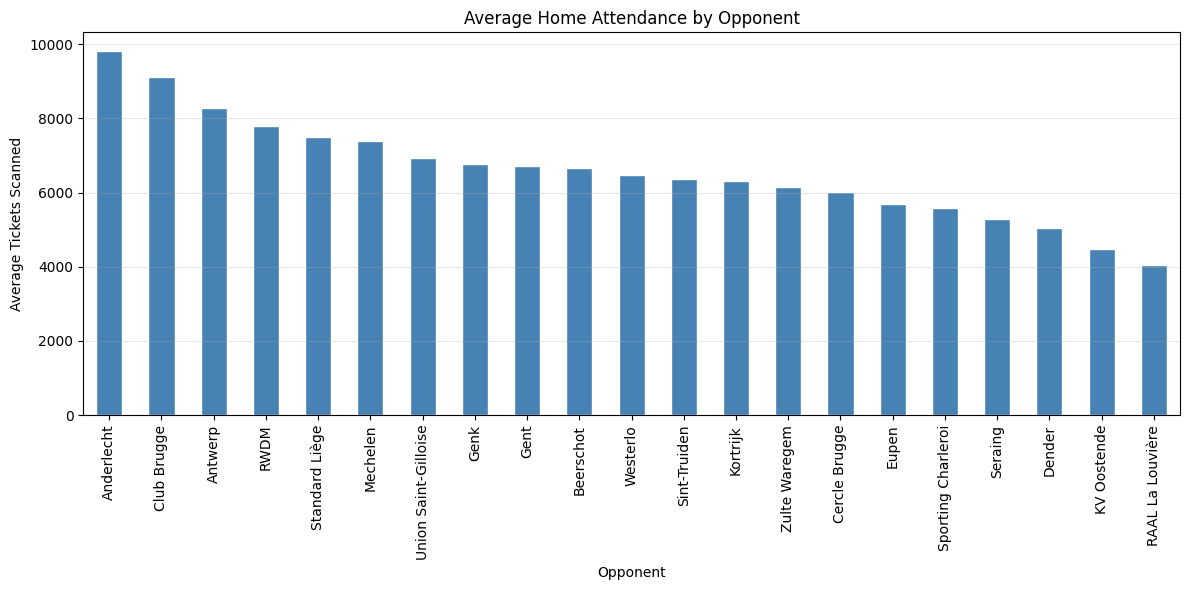

In [6]:
attendance_opponent = (
    analysis_df
    .groupby('away_team')['tickets_scanned']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
attendance_opponent.plot(
    kind='bar',
    color='steelblue',
    edgecolor='white'
)

plt.ylabel("Average Tickets Scanned")
plt.xlabel("Opponent")
plt.title("Average Home Attendance by Opponent")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Opponent Impact on Attendance

The opponent appears to have a strong influence on match attendance.  
Matches against well-known or traditionally stronger teams tend to attract larger crowds.

Fans are more motivated to attend games against high-profile opponents because these matches are perceived as more exciting and competitive.

Lower-profile opponents generally attract smaller audiences, suggesting that the perceived attractiveness of the opponent plays a significant role in driving stadium attendance.

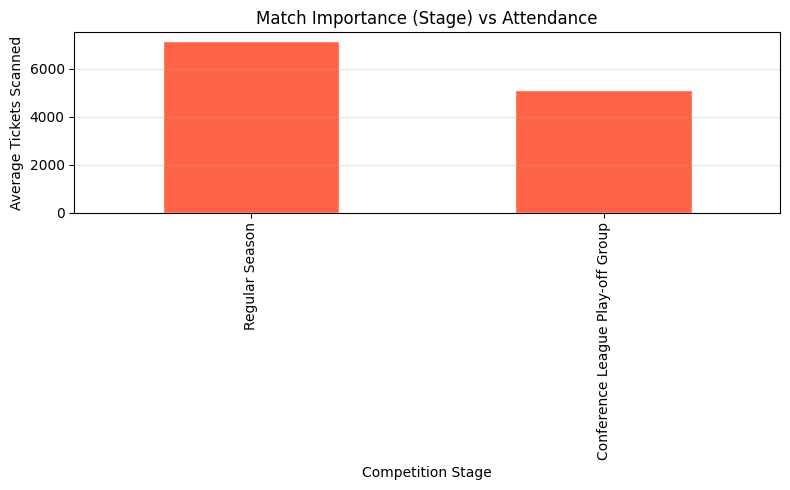

In [7]:
attendance_stage = (
    analysis_df
    .groupby('stage')['tickets_scanned']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

attendance_stage.plot(
    kind='bar',
    color='tomato',
    edgecolor='white'
)

plt.ylabel("Average Tickets Scanned")
plt.xlabel("Competition Stage")
plt.title("Match Importance (Stage) vs Attendance")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Match Importance and Attendance

The stage of the competition reflects the importance of a match.  
Matches in later stages or decisive games tend to attract more spectators.

This pattern suggests that fans are more willing to attend games that have greater sporting significance, such as key league matches or knockout stages.

Therefore, match importance is an important contextual factor influencing stadium attendance.

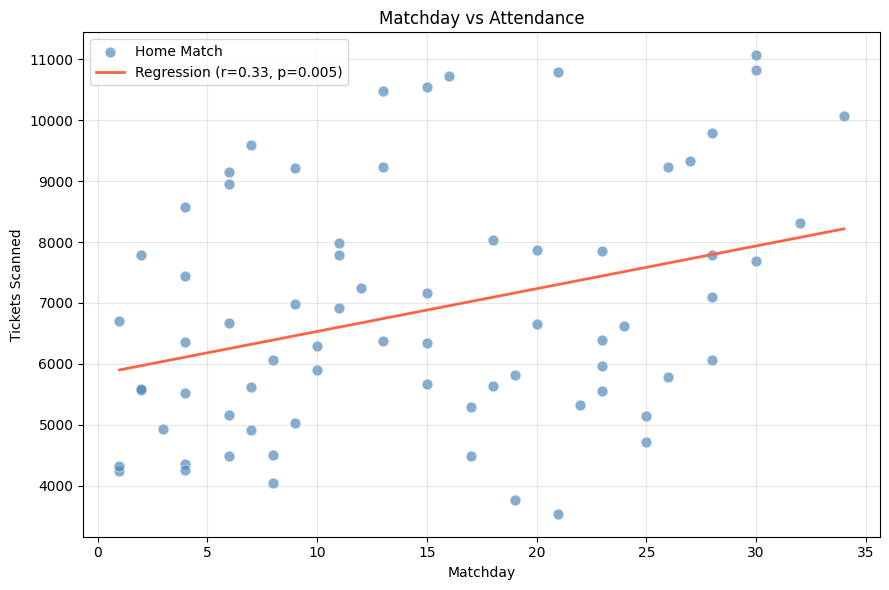

r = 0.328 | r² = 0.108 | p = 0.005


In [8]:
x = analysis_df['matchday']
y = analysis_df['tickets_scanned']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(9,6))

plt.scatter(
    x,
    y,
    alpha=0.65,
    edgecolors='white',
    linewidth=0.5,
    s=60,
    color='steelblue',
    label='Home Match'
)

plt.plot(
    x_line,
    y_line,
    color='tomato',
    linewidth=2,
    label=f'Regression (r={r_value:.2f}, p={p_value:.3f})'
)

plt.xlabel('Matchday')
plt.ylabel('Tickets Scanned')
plt.title('Matchday vs Attendance')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"r = {r_value:.3f} | r² = {r_value**2:.3f} | p = {p_value:.3f}")

### Regression Analysis: Matchday vs Attendance

The regression analysis explores whether the timing of a match during the season influences attendance.

The correlation coefficient (r) indicates the strength and direction of the relationship between matchday and attendance.

A positive value would suggest that later-season matches attract more spectators, potentially because the sporting stakes increase as the season progresses.

However, if the correlation is weak and statistically insignificant, it suggests that the timing within the season does not strongly influence attendance compared to other factors such as opponent or match importance.

In [9]:
top_matches = analysis_df.sort_values(
    by='tickets_scanned',
    ascending=False
)

top_matches[
    ['match_date', 'away_team', 'tickets_scanned']
].head(10)

,match_date,away_team,tickets_scanned
31,2024-03-17,Mechelen,11069.0
14,2023-03-19,Anderlecht,10827.0
27,2024-01-21,Anderlecht,10786.0
44,2024-12-01,Anderlecht,10723.0
24,2023-11-26,Club Brugge,10546.0
42,2024-11-02,Club Brugge,10485.0
16,2023-04-23,Standard Liège,10079.0
30,2024-03-02,Union Saint-Gilloise,9789.0
20,2023-09-17,Gent,9598.0
12,2023-02-26,Antwerp,9331.0


## Conclusion

This analysis examined how match context factors influence attendance at OH Leuven home matches.

The results suggest that:

- The opponent plays a significant role in attracting spectators.
- Matches against stronger or more popular teams tend to generate higher attendance.
- Match importance, represented by the competition stage, also increases spectator interest.
- The timing of the match within the season (matchday) shows a weaker relationship with attendance.

Overall, the findings indicate that the attractiveness and importance of a match are key drivers of stadium attendance.

In [12]:
df_model = analysis_df.copy()

df_model['season_numeric'] = df_model['season'].str.split('/').str[0].astype(int)

stage_map = {
    'Regular Season': 1,
    'Playoffs': 2,
    'Cup': 3
}
df_model['stage_numeric'] = df_model['stage'].map(stage_map)


def result_to_score(result):
    if pd.isna(result):
        return 0
    elif result.startswith('W'):
        return 1
    elif result.startswith('D'):
        return 0
    elif result.startswith('L'):
        return -1
    else:
        return 0

df_model['last_result_score'] = df_model['last_result_vs_opponent'].apply(result_to_score)


features = ['matchday', 'season_numeric', 'stage_numeric', 'last_result_score']
X = df_model[features]
y = df_model['tickets_scanned']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestRegressor(random_state=42, n_estimators=200)
model.fit(X_train, y_train)


predictions = model.predict(X_test)


mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Model Evaluation")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Model Evaluation
MAE: 1131.2910000000002
RMSE: 1307.1131904142808
R²: 0.5230756197024481


Explanation of the model code:

This code trains a Random Forest regression model to predict the number of tickets scanned for a home match (tickets_scanned). The model learns from match-related features, including:

Matchday – the chronological number of the match in the season.
Season – converted to a numeric year to allow the model to capture seasonal trends.
Stage – the importance of the match (Regular Season, Playoffs, Cup), converted into numeric values so the model can recognize that more important matches tend to attract more fans.
Last Result vs Opponent – the outcome of the previous match against the same opponent, encoded as +1 for a win, 0 for a draw or missing data, and -1 for a loss, allowing the model to consider the effect of recent performance on attendance.

The dataset is split into a training set (80%) and a test set (20%), and the Random Forest learns patterns from the training data to predict attendance on the test set.

After training, the model’s performance is evaluated using:

MAE (Mean Absolute Error) – the average absolute difference between predicted and actual attendance.
RMSE (Root Mean Squared Error) – a measure that penalizes larger errors more strongly.
R² (Coefficient of Determination) – indicates how much of the variation in attendance the model can explain.

In short, this model is trained to understand how matchday, season, match importance, and recent results influence fan attendance and can provide predictions for future matches based on these factors.